In [1]:
from dotenv import load_dotenv
import os

load_dotenv(r"D:\Practice\hipython\llm\.env", override=True)

PINECONE_API_KEY = os.environ['PINECONE_API_KEY']

In [6]:
from pinecone import Pinecone

pc = Pinecone(api_key=PINECONE_API_KEY)
assistant_name = "example-assistant"

# 1. 현재 존재하는 assistant 리스트 확인
existing_assistants = [a.name for a in pc.assistant.list_assistants()]

if assistant_name in existing_assistants:
    # 2. 이미 있으면 바로 연결
    assistant = pc.assistant.Assistant(assistant_name=assistant_name)
    print(f"기존 Assistant '{assistant_name}'에 연결되었습니다.")
else:
    # 3. 없으면 새로 생성
    assistant = pc.assistant.create_assistant(
        assistant_name=assistant_name,
        instructions="Answer in polite, short sentences. Use American English spelling and vocabulary.",
        timeout=30
    )
    print(f"새로운 Assistant '{assistant_name}'이(가) 생성되었습니다.")


기존 Assistant 'example-assistant'에 연결되었습니다.


In [8]:
from pinecone import Pinecone, ServerlessSpec

pc = Pinecone(api_key=PINECONE_API_KEY)
index_name = "embedding-3d"

# 1. 인덱스가 없는 경우에만 생성
if index_name not in pc.list_indexes().names():
    pc.create_index(
        name=index_name,
        dimension=3,
        metric="cosine",
        spec=ServerlessSpec(
            cloud="aws",
            region="us-east-1"
        )
    )
    print(f"Index '{index_name}'이(가) 새로 생성되었습니다.")
else:
    print(f"Index '{index_name}'이(가) 이미 존재합니다.")

# 2. 인덱스 연결
index = pc.Index(index_name)

# 3. 상태 확인
print(index.describe_index_stats())

# 4. 데이터 리스팅 (네임스페이스가 비어있으면 결과가 없을 수 있음)
for ids in index.list(namespace="embedding-3d-ns1"):
    print(ids)


Index 'embedding-3d'이(가) 이미 존재합니다.
{'_response_info': {'raw_headers': {'connection': 'keep-alive',
                                    'content-length': '148',
                                    'content-type': 'application/json',
                                    'date': 'Mon, 13 Apr 2026 05:43:28 GMT',
                                    'grpc-status': '0',
                                    'server': 'envoy',
                                    'x-envoy-upstream-service-time': '36',
                                    'x-pinecone-request-latency-ms': '36',
                                    'x-pinecone-response-duration-ms': '37'}},
 'dimension': 3,
 'index_fullness': 0.0,
 'memoryFullness': 0.0,
 'metric': 'cosine',
 'namespaces': {},
 'storageFullness': 0.0,
 'total_vector_count': 0,
 'vector_type': 'dense'}


## 벡터 저장하기 - 업서트

In [22]:
# 벡터를 인덱스에 업서트(upsert)합니다.
# "embedding-3d-ns1" 네임스페이스에 벡터를 추가합니다.
index.upsert(
    vectors=[
        {
            "id": "vec1",
            "values": [1.0, 1.5, 2.0],
            "metadata": {"genre": "drama"}
        }, {
            "id": "vec2",
            "values": [2.0, 1.0, 0.5],
            "metadata": {"genre": "action"}
        }, {
            "id": "vec3",
            "values": [0.1, 0.3, 0.5],      #vector=[0.1, 0.3, 0.7],
            "metadata": {"genre": "drama"}
        }, {
            "id": "vec4",
            "values": [1.0, 2.5, 3.5],      #vector=[0.1, 0.3, 0.7],
            "metadata": {"genre": "action"}
        }, {
            "id": "vec5",
            "values": [3.0, 1.2, 1.3],
            "metadata": {"genre": "action"}
        }, {
            "id": "vec6", 
            "values": [0.3, 1.1, 2.5],  #    vector=[0.1, 0.3, 0.7],
            "metadata": {"genre": "drama"}
        }
    ],
    namespace="embedding-3d-ns1"
)

UpsertResponse(upserted_count=6, _response_info={'raw_headers': {'date': 'Mon, 13 Apr 2026 06:18:54 GMT', 'content-type': 'application/json', 'content-length': '19', 'connection': 'keep-alive', 'x-pinecone-request-lsn': '2', 'x-pinecone-request-logical-size': '207', 'x-pinecone-request-latency-ms': '295', 'x-envoy-upstream-service-time': '296', 'x-pinecone-response-duration-ms': '296', 'grpc-status': '0', 'server': 'envoy'}})

## 생성 결과를 확인

In [23]:
index.describe_index_stats()

{'dimension': 3,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'embedding-3d-ns1': {'vector_count': 6}},
 'total_vector_count': 6,
 'vector_type': 'dense'}

{'dimension': 3,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'embedding-3d-ns1': {'vector_count': 6}},
 'total_vector_count': 6,
 'vector_type': 'dense'}

In [24]:
# embedding-3d-ns1 네임스페이스의 모든 레코드 id를 조회합니다.
for ids in index.list(namespace="embedding-3d-ns1"):
    print(ids)

['vec1', 'vec2', 'vec3', 'vec4', 'vec5', 'vec6']


## 쿼리를 실행

In [25]:
response = index.query(
    namespace="embedding-3d-ns1",
    vector=[0.1, 0.3, 0.7],
    top_k=3,
    include_values=True,
    include_metadata=True
)

print(response)

QueryResponse(matches=[{'id': 'vec6',
 'metadata': {'genre': 'drama'},
 'score': 1.00006485,
 'values': [0.3, 1.1, 2.5]}, {'id': 'vec3',
 'metadata': {'genre': 'drama'},
 'score': 0.990785182,
 'values': [0.1, 0.3, 0.5]}, {'id': 'vec4',
 'metadata': {'genre': 'action'},
 'score': 0.972905457,
 'values': [1.0, 2.5, 3.5]}], namespace='embedding-3d-ns1', usage={'read_units': 1}, _response_info={'raw_headers': {'date': 'Mon, 13 Apr 2026 06:19:07 GMT', 'content-type': 'application/json', 'content-length': '337', 'connection': 'keep-alive', 'x-pinecone-max-indexed-lsn': '2', 'x-pinecone-request-latency-ms': '38', 'x-envoy-upstream-service-time': '38', 'x-pinecone-response-duration-ms': '39', 'grpc-status': '0', 'server': 'envoy'}})


In [26]:
{'matches': [{'id': 'vec6',
              'metadata': {'genre': 'drama'},
              'score': 1.00006485,
              'values': [0.3, 1.1, 2.5]},
             {'id': 'vec3',
              'metadata': {'genre': 'drama'},
              'score': 0.990785182,
              'values': [0.1, 0.3, 0.5]},
             {'id': 'vec4',
              'metadata': {'genre': 'action'},
              'score': 0.972905457,
              'values': [1.0, 2.5, 3.5]}],
 'namespace': 'embedding-3d-ns1',
 'usage': {'read_units': 1}}

{'matches': [{'id': 'vec6',
   'metadata': {'genre': 'drama'},
   'score': 1.00006485,
   'values': [0.3, 1.1, 2.5]},
  {'id': 'vec3',
   'metadata': {'genre': 'drama'},
   'score': 0.990785182,
   'values': [0.1, 0.3, 0.5]},
  {'id': 'vec4',
   'metadata': {'genre': 'action'},
   'score': 0.972905457,
   'values': [1.0, 2.5, 3.5]}],
 'namespace': 'embedding-3d-ns1',
 'usage': {'read_units': 1}}

In [27]:
response = index.query(
    namespace="embedding-3d-ns1",
    vector=[0.1, 0.3, 0.7],
    top_k=3,
    include_values=True,
    include_metadata=True,
    filter={
        "genre": {"$eq": "drama"}
    }
)

print(response)

QueryResponse(matches=[{'id': 'vec6',
 'metadata': {'genre': 'drama'},
 'score': 1.00006485,
 'values': [0.3, 1.1, 2.5]}, {'id': 'vec3',
 'metadata': {'genre': 'drama'},
 'score': 0.990785182,
 'values': [0.1, 0.3, 0.5]}, {'id': 'vec1',
 'metadata': {'genre': 'drama'},
 'score': 0.943127871,
 'values': [1.0, 1.5, 2.0]}], namespace='embedding-3d-ns1', usage={'read_units': 1}, _response_info={'raw_headers': {'date': 'Mon, 13 Apr 2026 06:19:13 GMT', 'content-type': 'application/json', 'content-length': '334', 'connection': 'keep-alive', 'x-pinecone-max-indexed-lsn': '2', 'x-pinecone-request-latency-ms': '2', 'x-envoy-upstream-service-time': '6', 'x-pinecone-response-duration-ms': '11', 'grpc-status': '0', 'server': 'envoy'}})


## 참고) 벡터 공간 시각화하기

In [28]:
from itertools import chain

ns = "embedding-3d-ns1"

# ID 전부 모으기 (list()는 페이지 단위로 ID 리스트를 내줌)
all_ids = list(chain.from_iterable(index.list(namespace=ns)))

# 벡터 가져오기
resp = index.fetch(ids=all_ids, namespace=ns)   # ← FetchResponse 객체
vec_map = resp.vectors                          # dict[str, Vector]

# 값/메타데이터 사용 예
for vid, v in vec_map.items():
    print(vid, v.values)         # 값(list[float])
    # print(v.metadata)          # 메타데이터가 있으면
    
ids = list(vec_map.keys())
values = [vec.values for vec in vec_map.values()]

# 새 쿼리 벡터 추가
ids.append("qv")
values.append([0.1, 0.3, 0.7])   # <- dim=3 환경과 일치

print(ids)
print(values)    

vec1 [1.0, 1.5, 2.0]
vec5 [3.0, 1.2, 1.3]
vec3 [0.1, 0.3, 0.5]
vec2 [2.0, 1.0, 0.5]
vec6 [0.3, 1.1, 2.5]
vec4 [1.0, 2.5, 3.5]
['vec1', 'vec5', 'vec3', 'vec2', 'vec6', 'vec4', 'qv']
[[1.0, 1.5, 2.0], [3.0, 1.2, 1.3], [0.1, 0.3, 0.5], [2.0, 1.0, 0.5], [0.3, 1.1, 2.5], [1.0, 2.5, 3.5], [0.1, 0.3, 0.7]]


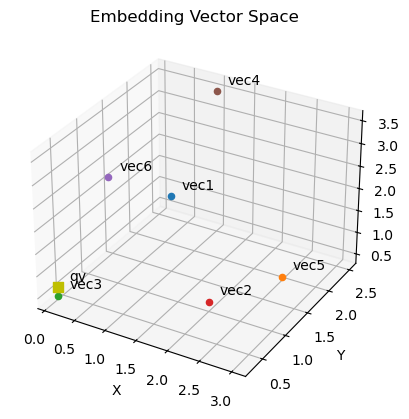

In [29]:
import matplotlib.pyplot as plt

# 3D 플롯을 생성합니다.
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# 각 벡터의 ID와 값을 사용하여 3D 공간에 점을 그립니다.
for i, id in enumerate(ids):
    if id == "qv":
        # 쿼리 벡터는 노란색 사각형으로 표시합니다.
        ax.scatter(values[i][0], values[i][1], values[i][2], label=id, color='y', s=50, marker='s')
        ax.text(values[i][0] + 0.1, values[i][1] + 0.1, values[i][2] + 0.1, id)
    else:
        # 나머지 벡터는 기본 색상으로 표시합니다.
        ax.scatter(values[i][0], values[i][1], values[i][2], label=id)
        ax.text(values[i][0] + 0.1, values[i][1] + 0.1, values[i][2] + 0.1, id)

# 축 레이블과 제목을 설정합니다.
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Embedding Vector Space')

# 플롯을 표시합니다.
plt.show()

## 동작 확인하기

In [ ]:
from dotenv import load_dotenv
import os
# load_dotenv()
load_dotenv(r"D:\Practice\hipython\llm\.env", override=True)

from pinecone import Pinecone

pc = Pinecone(api_key=os.environ['PINECONE_API_KEY'])

# 인덱스 목록 확인
indexes = pc.list_indexes().names()
print(f"생성된 인덱스: {indexes}")

# 인덱스 상태 확인
index_name = os.environ['PINECONE_INDEX_NAME']

if index_name in indexes:
    index = pc.Index(index_name)
    stats = index.describe_index_stats()
    print(f"벡터 수: {stats['total_vector_count']}")
    print(f"dimension: {stats['dimension']}")

생성된 인덱스: ['embedding-3d']
index_name: embedding-3d
벡터 수: 6
dimension: 3
